In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1790107402.514895   25818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790107402.869589   25818 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790107404.905337   25818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790107408.051445   25818 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_DIR = "/mnt/e/kartik/Mango flower disease detection DL project"

DATASET_DIR = os.path.join(PROJECT_DIR, "mango_dataset")

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

MODEL_DIR = os.path.join(DATASET_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 7

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Found 667 files belonging to 7 classes.


W0000 00:00:1790107503.477561   25818 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790107503.678515   25818 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 139 files belonging to 7 classes.
Found 151 files belonging to 7 classes.
Classes:
0 : anthracnose
1 : anthracnose & mango malformation
2 : anthracnose & powdery mildew
3 : healthy
4 : mango malformation
5 : mango malformation & powdery mildew
6 : powdery mildew


In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.10)
])

In [6]:
def sparse_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)

        # Prevent numerical issues
        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon()
        )

        # Probability assigned to the correct class
        indices = tf.stack(
            [tf.range(tf.shape(y_true)[0]), y_true],
            axis=1
        )

        p_t = tf.gather_nd(y_pred, indices)

        focal_term = tf.pow(1.0 - p_t, gamma)

        loss_value = -alpha * focal_term * tf.math.log(p_t)

        return tf.reduce_mean(loss_value)

    return loss

In [7]:
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model_C = keras.Model(inputs, outputs)

model_C.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,084,183 (23.21 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [8]:
model_C.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

In [9]:
checkpoint_path_C = os.path.join(
    MODEL_DIR,
    "experiment_C_focal_loss_best.keras"
)

early_C = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_C = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_C = keras.callbacks.ModelCheckpoint(
    checkpoint_path_C,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [10]:
history_C = model_C.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=12,
    callbacks=[
        early_C,
        reduce_C,
        checkpoint_C
    ]
)

Epoch 1/12


/home/aditya/mango-wsl-venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790107577.703535   26533 service.cc:153] XLA service 0x79fe80072210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790107577.703572   26533 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790107578.025754   26533 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790107580.213165   26533 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790107580.777540   26533 dot_merger.cc:4

 1/21 ━━━━━━━━━━━━━━━━━━━━ 9:51 30s/step - accuracy: 0.0625 - loss: 0.4723

I0000 00:00:1790107599.565551   26533 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.4178 - loss: 0.2736

I0000 00:00:1790107609.548968   26531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18796__.268
E0000 00:00:1790107610.857810   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790107611.126702   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790107611.786811   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4198 - loss: 0.2687   

E0000 00:00:1790107633.527677   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790107634.357249   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790107637.147440   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.16833, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_C_focal_loss_best.keras

Epoch 1: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_C_focal_loss_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.4198 - loss: 0.2687 - val_accuracy: 0.6043 - val_loss: 0.1683 - learning_rate: 0.0010
Epoch 2/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.6072 - loss: 0.1541
Epoch 2: val_loss improved from 0.16833 to 0.11890, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_C_focal_loss_best.keras

Epoch 2: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_C_focal_loss_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 661ms/step - accuracy: 0.6072 - loss: 0.1541 - val_accuracy: 0.6331 - val_loss: 0.1189 - lea

In [11]:
best_model_C = keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "experiment_C_focal_loss_best.keras"
    ),
    custom_objects={
        "loss": sparse_focal_loss(gamma=2.0, alpha=0.25)
    }
)

print("Experiment C best model loaded successfully.")

Experiment C best model loaded successfully.


In [12]:
# ==============================
# EXPERIMENT C — PREDICTIONS
# ==============================

# Validation
y_val_true_C = np.concatenate(
    [labels.numpy() for images, labels in validation_ds]
)

y_val_prob_C = best_model_C.predict(
    validation_ds,
    verbose=1
)

y_val_pred_C = np.argmax(
    y_val_prob_C,
    axis=1
)


# Test
y_test_true_C = np.concatenate(
    [labels.numpy() for images, labels in test_ds]
)

y_test_prob_C = best_model_C.predict(
    test_ds,
    verbose=1
)

y_test_pred_C = np.argmax(
    y_test_prob_C,
    axis=1
)

print("Prediction completed.")

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step

E0000 00:00:1790107868.318002   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790107869.261432   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790107870.591776   26531 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step 
Prediction completed.


In [13]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("EXPERIMENT C — VALIDATION CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_val_true_C,
        y_val_pred_C,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

val_accuracy_C = accuracy_score(
    y_val_true_C,
    y_val_pred_C
)

val_macro_precision_C = precision_score(
    y_val_true_C,
    y_val_pred_C,
    average="macro",
    zero_division=0
)

val_macro_recall_C = recall_score(
    y_val_true_C,
    y_val_pred_C,
    average="macro",
    zero_division=0
)

val_macro_f1_C = f1_score(
    y_val_true_C,
    y_val_pred_C,
    average="macro",
    zero_division=0
)

val_weighted_f1_C = f1_score(
    y_val_true_C,
    y_val_pred_C,
    average="weighted",
    zero_division=0
)

print(f"Macro Precision: {val_macro_precision_C}")
print(f"Macro Recall:    {val_macro_recall_C}")
print(f"Macro F1:        {val_macro_f1_C}")
print(f"Weighted F1:     {val_weighted_f1_C}")

EXPERIMENT C — VALIDATION CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8056    0.9355    0.8657        31
   anthracnose & mango malformation     1.0000    0.6667    0.8000         3
       anthracnose & powdery mildew     0.6897    0.7407    0.7143        27
                            healthy     1.0000    0.9375    0.9677        32
                 mango malformation     0.8750    0.8750    0.8750        16
mango malformation & powdery mildew     0.6667    0.4000    0.5000         5
                     powdery mildew     0.7826    0.7200    0.7500        25

                           accuracy                         0.8273       139
                          macro avg     0.8314    0.7536    0.7818       139
                       weighted avg     0.8309    0.8273    0.8255       139

Macro Precision: 0.8313551557554557
Macro Recall:    0.7536273254821643
Macro F1:        0.78181418450

In [14]:
print("=" * 80)
print("EXPERIMENT C — TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test_true_C,
        y_test_pred_C,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

test_accuracy_C = accuracy_score(
    y_test_true_C,
    y_test_pred_C
)

test_macro_precision_C = precision_score(
    y_test_true_C,
    y_test_pred_C,
    average="macro",
    zero_division=0
)

test_macro_recall_C = recall_score(
    y_test_true_C,
    y_test_pred_C,
    average="macro",
    zero_division=0
)

test_macro_f1_C = f1_score(
    y_test_true_C,
    y_test_pred_C,
    average="macro",
    zero_division=0
)

test_weighted_f1_C = f1_score(
    y_test_true_C,
    y_test_pred_C,
    average="weighted",
    zero_division=0
)

print(f"Macro Precision: {test_macro_precision_C}")
print(f"Macro Recall:    {test_macro_recall_C}")
print(f"Macro F1:        {test_macro_f1_C}")
print(f"Weighted F1:     {test_weighted_f1_C}")

EXPERIMENT C — TEST CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8387    0.8125    0.8254        32
   anthracnose & mango malformation     1.0000    0.6000    0.7500         5
       anthracnose & powdery mildew     0.7241    0.7241    0.7241        29
                            healthy     0.9143    0.9412    0.9275        34
                 mango malformation     0.8571    1.0000    0.9231        18
mango malformation & powdery mildew     1.0000    0.8333    0.9091         6
                     powdery mildew     0.7037    0.7037    0.7037        27

                           accuracy                         0.8212       151
                          macro avg     0.8626    0.8021    0.8233       151
                       weighted avg     0.8235    0.8212    0.8197       151

Macro Precision: 0.8625685547980161
Macro Recall:    0.8021216340942507
Macro F1:        0.8232775034552718


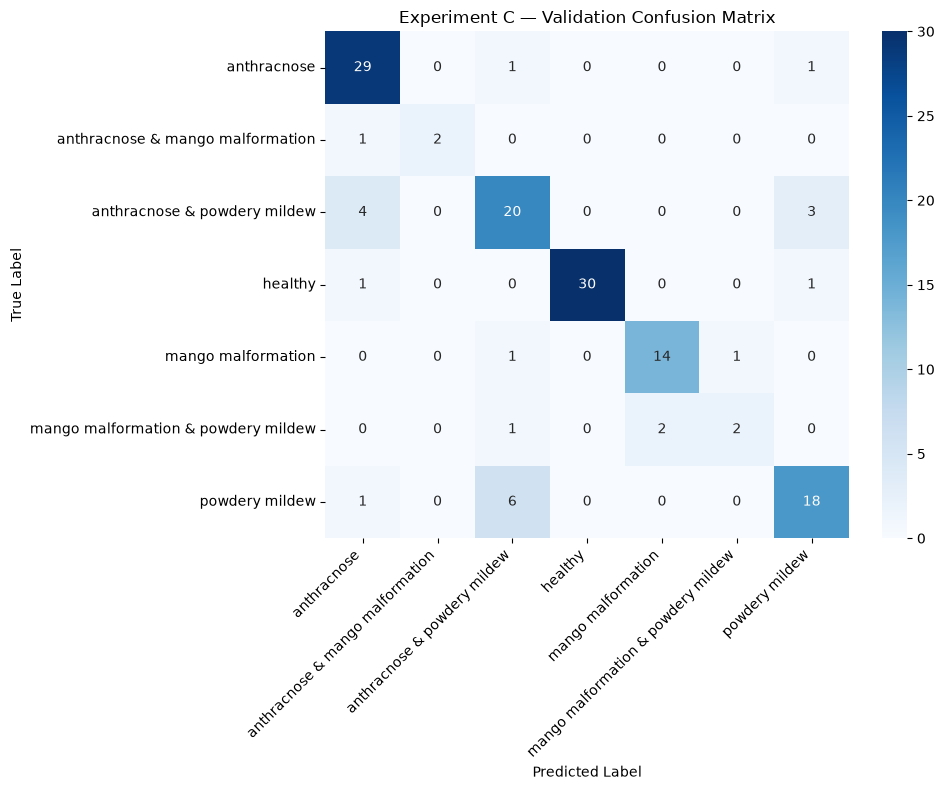

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_val_C = confusion_matrix(
    y_val_true_C,
    y_val_pred_C
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_val_C,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Experiment C — Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

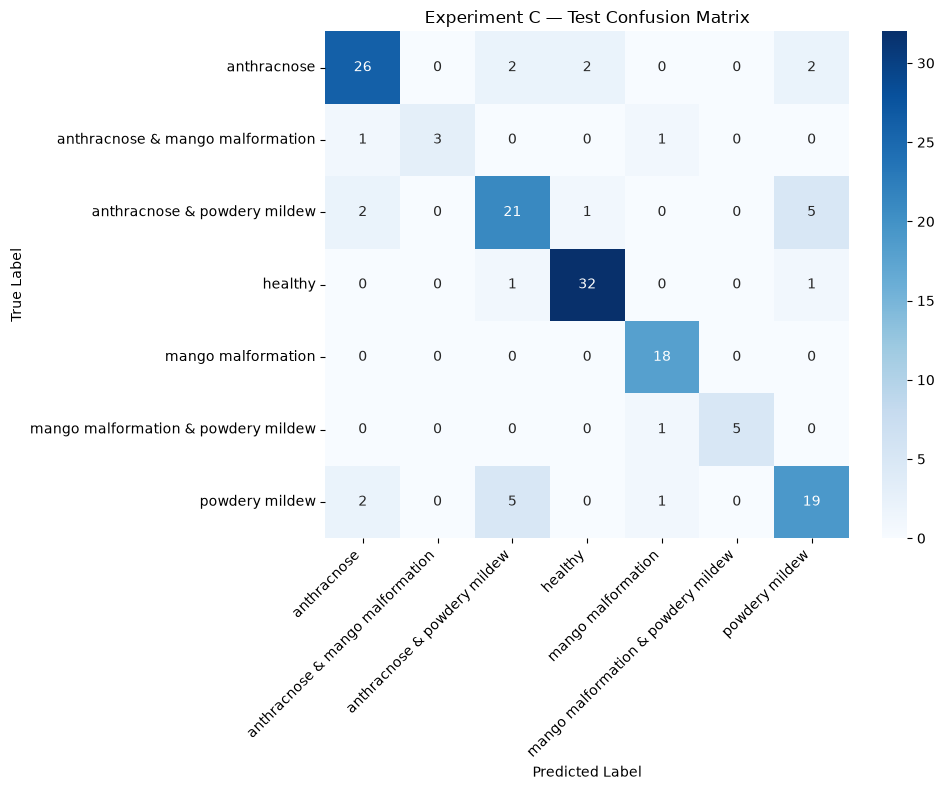

In [16]:
cm_test_C = confusion_matrix(
    y_test_true_C,
    y_test_pred_C
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_test_C,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Experiment C — Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
val_recall_C = recall_score(
    y_val_true_C,
    y_val_pred_C,
    average=None,
    zero_division=0
)

test_recall_C = recall_score(
    y_test_true_C,
    y_test_pred_C,
    average=None,
    zero_division=0
)

print("=" * 80)
print("EXPERIMENT C — PER-CLASS RECALL")
print("=" * 80)

for i, class_name in enumerate(class_names):
    print(
        f"{class_name:40s} "
        f"Validation: {val_recall_C[i]:.4f}   "
        f"Test: {test_recall_C[i]:.4f}"
    )

EXPERIMENT C — PER-CLASS RECALL
anthracnose                              Validation: 0.9355   Test: 0.8125
anthracnose & mango malformation         Validation: 0.6667   Test: 0.6000
anthracnose & powdery mildew             Validation: 0.7407   Test: 0.7241
healthy                                  Validation: 0.9375   Test: 0.9412
mango malformation                       Validation: 0.8750   Test: 1.0000
mango malformation & powdery mildew      Validation: 0.4000   Test: 0.8333
powdery mildew                           Validation: 0.7200   Test: 0.7037


In [18]:
print("=" * 70)
print("EXPERIMENT C — FINAL SUMMARY")
print("=" * 70)

print(f"Validation Accuracy    : {val_accuracy_C:.4f}")
print(f"Validation Macro F1    : {val_macro_f1_C:.4f}")
print(f"Validation Macro Recall: {val_macro_recall_C:.4f}")

print()

print(f"Test Accuracy          : {test_accuracy_C:.4f}")
print(f"Test Macro F1          : {test_macro_f1_C:.4f}")
print(f"Test Macro Recall      : {test_macro_recall_C:.4f}")

print("=" * 70)

EXPERIMENT C — FINAL SUMMARY
Validation Accuracy    : 0.8273
Validation Macro F1    : 0.7818
Validation Macro Recall: 0.7536

Test Accuracy          : 0.8212
Test Macro F1          : 0.8233
Test Macro Recall      : 0.8021
